<a href="https://colab.research.google.com/github/ItsMadtoEvil/Weather-Data-Analysis/blob/main/Weather_Data_Analysis_Using_NumPy%2C_Pandas%2C_and_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ==========================================
# Weather Data Analysis Using Pandas, NumPy, and Matplotlib
# ==========================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

In [7]:
# ------------------------------------------
# Load Dataset
# ------------------------------------------
url = "https://raw.githubusercontent.com/ItsMadtoEvil/Weather-Data-Analysis/main/weather_dataset_2025.csv"
df = pd.read_csv(url)

In [8]:
# ------------------------------------------
# Inspect Data
# ------------------------------------------
print("First 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
         Date    City  Temperature_C  Humidity_%  Wind_Speed_km_h  \
0  2025-01-01  Riyadh           15.8          94             21.0   
1  2025-01-01  Jeddah           31.5          54             25.3   
2  2025-01-01  Dammam           30.4          33              8.6   
3  2025-01-01   Dubai           34.0          37             18.7   
4  2025-01-01    Doha           28.3          32              6.8   

   Precipitation_mm      Condition  
0              0.00         Cloudy  
1              3.71          Windy  
2              3.14  Partly Cloudy  
3              0.00          Foggy  
4              0.00          Rainy  

Data Types:
Date                 object
City                 object
Temperature_C       float64
Humidity_%            int64
Wind_Speed_km_h     float64
Precipitation_mm    float64
Condition            object
dtype: object

Missing Values:
Date                0
City                0
Temperature_C       0
Humidity_%          0
Wind_Speed_km_h     0

In [9]:
# ------------------------------------------
# Data Cleaning
# ------------------------------------------
# Fill missing values
df.fillna(method='ffill', inplace=True)

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

/tmp/ipykernel_3677/139714034.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [10]:
# ------------------------------------------
# Descriptive Statistics Using NumPy
# ------------------------------------------
print("\nTemperature Statistics")
print("Mean:", np.mean(df['Temperature_C']))
print("Median:", np.median(df['Temperature_C']))
print("Standard Deviation:", np.std(df['Temperature_C']))

print("\nHumidity Statistics")
print("Mean:", np.mean(df['Humidity_%']))
print("Median:", np.median(df['Humidity_%']))
print("Standard Deviation:", np.std(df['Humidity_%']))

print("\nPrecipitation Statistics")
print("Mean:", np.mean(df['Precipitation_mm']))
print("Median:", np.median(df['Precipitation_mm']))
print("Standard Deviation:", np.std(df['Precipitation_mm']))


Temperature Statistics
Mean: 24.992310502283104
Median: 25.0
Standard Deviation: 11.544072121465504

Humidity Statistics
Mean: 57.675981735159816
Median: 58.0
Standard Deviation: 21.851567309902745

Precipitation Statistics
Mean: 3.1540931506849317
Median: 1.98
Standard Deviation: 3.6239683380962013


In [17]:
# ------------------------------------------
# Summary Statistics
# ------------------------------------------
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
                      Date  Temperature_C   Humidity_%  Wind_Speed_km_h  \
count                 5475    5475.000000  5475.000000      5475.000000   
mean   2025-07-02 00:00:00      24.992311    57.675982        20.045479   
min    2025-01-01 00:00:00       5.000000    20.000000         0.000000   
25%    2025-04-02 00:00:00      15.000000    39.000000        10.100000   
50%    2025-07-02 00:00:00      25.000000    58.000000        20.000000   
75%    2025-10-01 00:00:00      35.100000    77.000000        30.000000   
max    2025-12-31 00:00:00      45.000000    95.000000        40.000000   
std                    NaN      11.545127    21.853563        11.599011   

       Precipitation_mm        Month  
count       5475.000000  5475.000000  
mean           3.154093     6.526027  
min            0.000000     1.000000  
25%            0.000000     4.000000  
50%            1.980000     7.000000  
75%            5.355000    10.000000  
max           21.370000    12.0

In [11]:
# ------------------------------------------
# Monthly Analysis
# ------------------------------------------
monthly_data = df.groupby('Month')[['Temperature_C',
                                    'Humidity_%',
                                    'Precipitation_mm']].mean()

print("\nMonthly Average Values")
print(monthly_data)



Monthly Average Values
       Temperature_C  Humidity_%  Precipitation_mm
Month                                             
1          25.199355   58.387097          3.319376
2          24.302143   57.938095          2.986190
3          24.199355   55.959140          3.397441
4          25.460444   57.737778          3.140733
5          25.263441   56.384946          2.852516
6          25.101333   58.968889          3.044467
7          25.370968   57.989247          3.282774
8          24.620860   57.655914          3.176882
9          24.848444   55.464444          3.057356
10         25.115054   57.393548          3.201312
11         25.644667   59.244444          3.501000
12         24.749892   59.036559          2.876925


In [12]:
# ------------------------------------------
# Seasonal Analysis
# ------------------------------------------
seasonal_data = df.groupby('Season')[['Temperature_C',
                                      'Humidity_%',
                                      'Precipitation_mm']].mean()

print("\nSeasonal Average Values")
print(seasonal_data)



Seasonal Average Values
        Temperature_C  Humidity_%  Precipitation_mm
Season                                             
Autumn      25.201758   57.367766          3.252652
Spring      24.969130   56.682609          3.130116
Summer      25.030290   58.196377          3.169384
Winter      24.765407   58.471111          3.063319


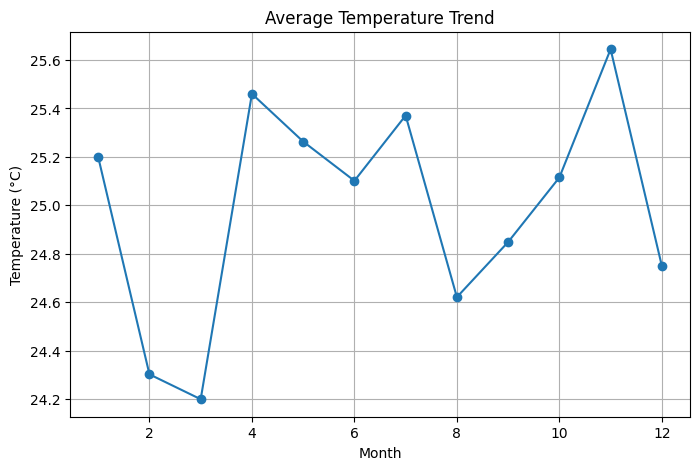

In [13]:
# ------------------------------------------
# Line Plot: Average Temperature Trend
# ------------------------------------------
monthly_temp = df.groupby('Month')['Temperature_C'].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index,
         monthly_temp.values,
         marker='o')
plt.title('Average Temperature Trend')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

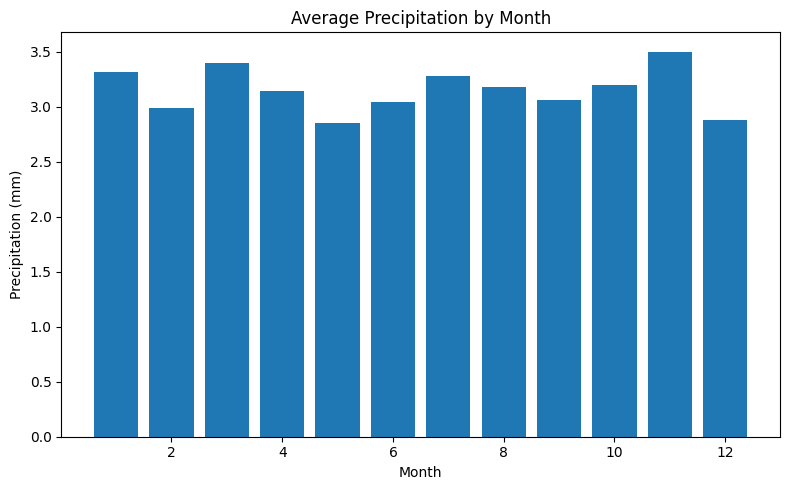

In [21]:
# ------------------------------------------
# Bar Plot: Average Precipitation by Month
# ------------------------------------------
monthly_precip = df.groupby('Month')['Precipitation_mm'].mean()

plt.figure(figsize=(8,5))
plt.bar(monthly_precip.index,
        monthly_precip.values)
plt.title('Average Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.tight_layout()
plt.show()


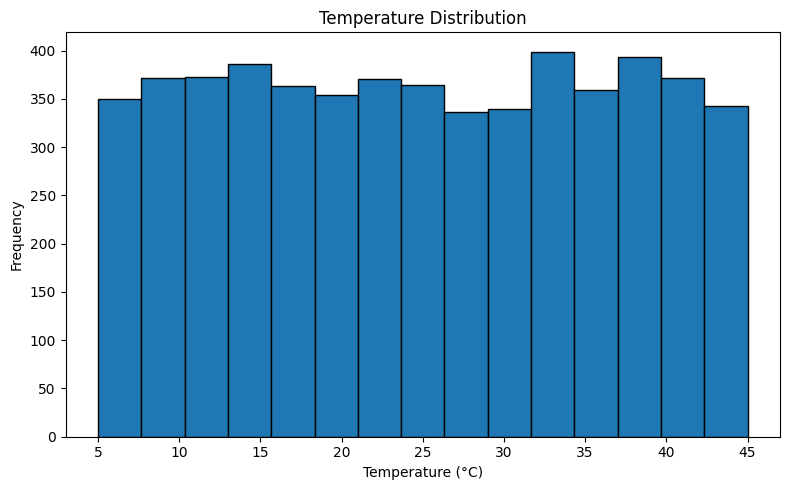

In [20]:
# ------------------------------------------
# Histogram: Temperature Distribution
# ------------------------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Temperature_C'], bins=15,edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [16]:
# ------------------------------------------
# Identify Extreme Weather
# ------------------------------------------

# Top 5% hottest days
temp_threshold = np.percentile(df['Temperature_C'], 95)
extreme_temp_days = df[df['Temperature_C'] >= temp_threshold]

print("\nExtreme Temperature Days:")
print(extreme_temp_days[['Date', 'City', 'Temperature_C']])

# Top 5% precipitation days
precip_threshold = np.percentile(df['Precipitation_mm'], 95)
extreme_precip_days = df[df['Precipitation_mm'] >= precip_threshold]

print("\nExtreme Precipitation Days:")
print(extreme_precip_days[['Date', 'City', 'Precipitation_mm']])


Extreme Temperature Days:
           Date       City  Temperature_C
17   2025-01-02     Dammam           43.7
59   2025-01-04  Singapore           44.8
73   2025-01-05     Mumbai           43.5
87   2025-01-06     Berlin           43.4
107  2025-01-08     Dammam           44.0
...         ...        ...            ...
5410 2025-12-27     Sydney           43.1
5418 2025-12-28      Dubai           44.0
5423 2025-12-28      Tokyo           43.5
5455 2025-12-30     Sydney           43.9
5474 2025-12-31  Singapore           44.3

[277 rows x 3 columns]

Extreme Precipitation Days:
           Date     City  Precipitation_mm
11   2025-01-01  Toronto             15.56
16   2025-01-02   Jeddah             11.30
26   2025-01-02  Toronto             13.94
31   2025-01-03   Jeddah             11.97
46   2025-01-04   Jeddah             11.62
...         ...      ...               ...
5435 2025-12-29    Cairo             13.59
5442 2025-12-29   Berlin             11.03
5446 2025-12-30   Jeddah     